# Воспроизведение сценариев Банка России

Этот ноутбук воспроизводит расчёты и графики модели инфляции, разрыва выпуска и ключевой ставки для 4 сценариев денежно-кредитной политикиб взятых из аналитической записки ЦБ РФ [[ссылка](https://www.cbr.ru/Content/Document/File/187425/analytic_note_20260310_dip.pdf)]

## Что внутри
- запуск симуляции для 4 стратегий ставок:
- построение основных графиков по каждому сценарию;
- графики потерь темпов роста ВВП;
- сравнительные графики между сценариями.



## Сценарии
- **Сценарий 1**: ставка фиксирована на 3%;
- **Сценарий 2**: ставка следует за текущей инфляцией;
- **Сценарий 3**: 1 год ошибки, затем переход к правилу Тейлора;
- **Сценарий 4**: 3 года ошибки, затем переход к правилу Тейлора.

## Подготовка и импорты

Ниже подключаются модули проекта (`simulation`, `policies`, `plots`) и функции для построения всех графиков.

In [1]:
# При необходимости установить зависимости (раскомментируйте):
# %pip install -e ..

# Текущая версия python в ядре ноутбука
import sys
print(sys.version)

3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]


In [2]:
import os, sys
sys.path.append(os.path.abspath(".."))


from plots import (
    plot_cumulative_losses_comparison_4_results,
    plot_key_rate_comparison,
    plot_key_rate_comparison_4_results,
    plot_losses,
    plot_main_indicators,
)
from policies import (
    build_scenario_1_strategy,
    build_scenario_2_strategy,
    build_scenario_3_strategy,
    build_scenario_4_strategy,
)
from simulation import simulate_scenario


## Расчёт сценариев и постройка графиков

Сначала считаем все 4 сценария и сохраняем результаты в переменные `scen1`...`scen4`.
Далее графики будут идти по одному, и перед каждым будет краткое пояснение.

### Расчёт

In [3]:
# Расчёт всех 4 сценариев
scen1 = simulate_scenario(build_scenario_1_strategy())
scen2 = simulate_scenario(build_scenario_2_strategy())
scen3 = simulate_scenario(build_scenario_3_strategy())
scen4 = simulate_scenario(build_scenario_4_strategy())

### Графики

#### Графики инфляции, ВВП и потенциального ВВП + график номинальный и реальной ставки,

##### График 1. Основные индикаторы — сценарий 1

Сценарий 1: ключевая ставка фиксирована на уровне 3%. Здесь видно, как это влияет на инфляцию, выпуск и реальные ставки.

*Соотвествует графикам на стр. 11-12 в записке цб рф*

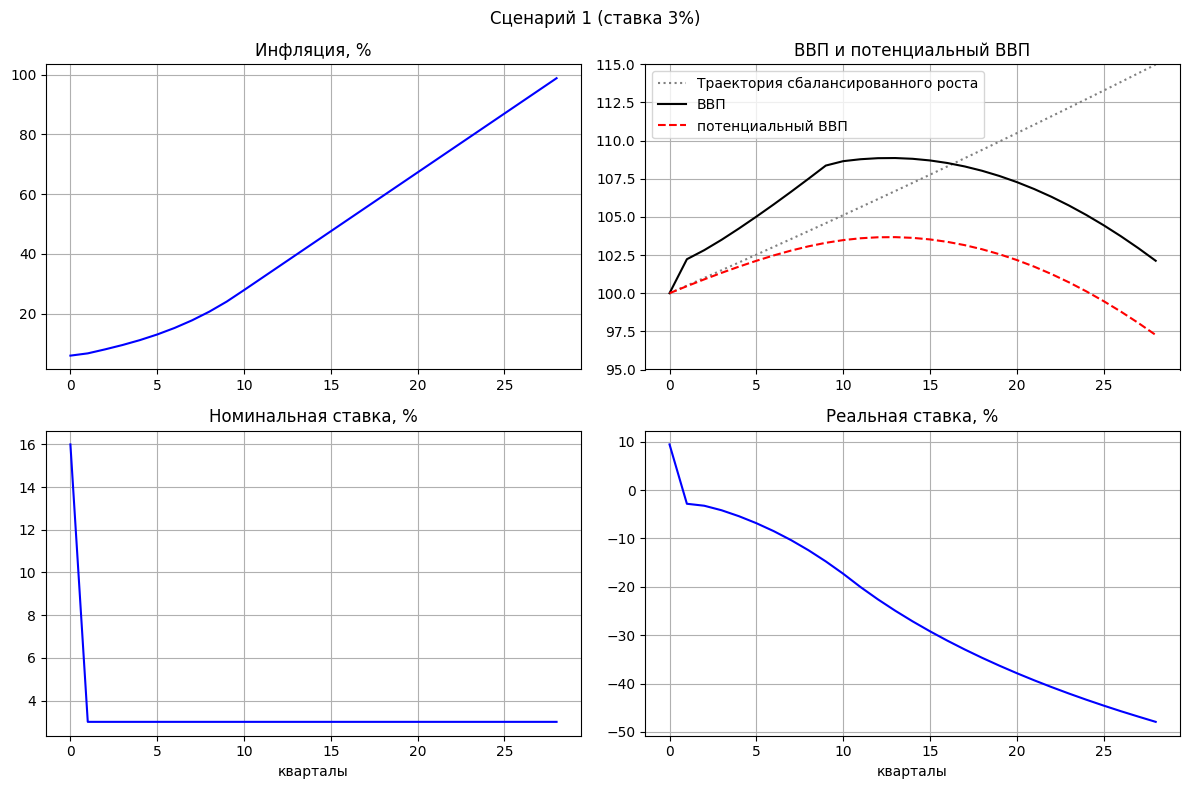

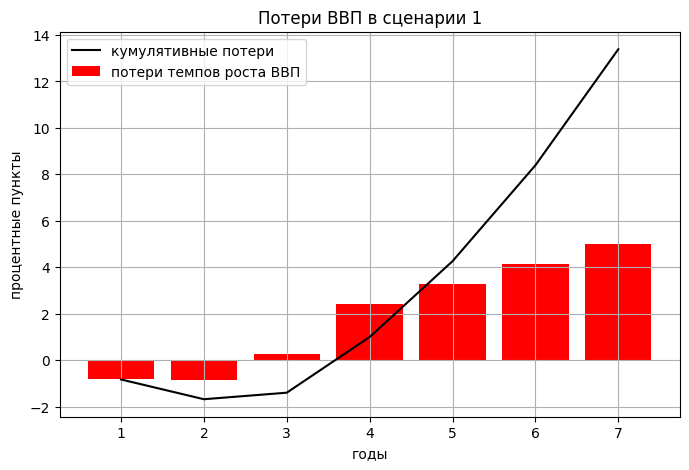

In [4]:
plot_main_indicators(scen1, 'Сценарий 1 (ставка 3%)')
plot_losses(scen1, 'Потери ВВП в сценарии 1')

##### График 2. Основные индикаторы — сценарий 2

Сценарий 2: ставка равна текущей инфляции. Это более адаптивное поведение по сравнению с фиксированной ставкой.

*Соотвествует графикам на стр. 13 в записке цб рф*

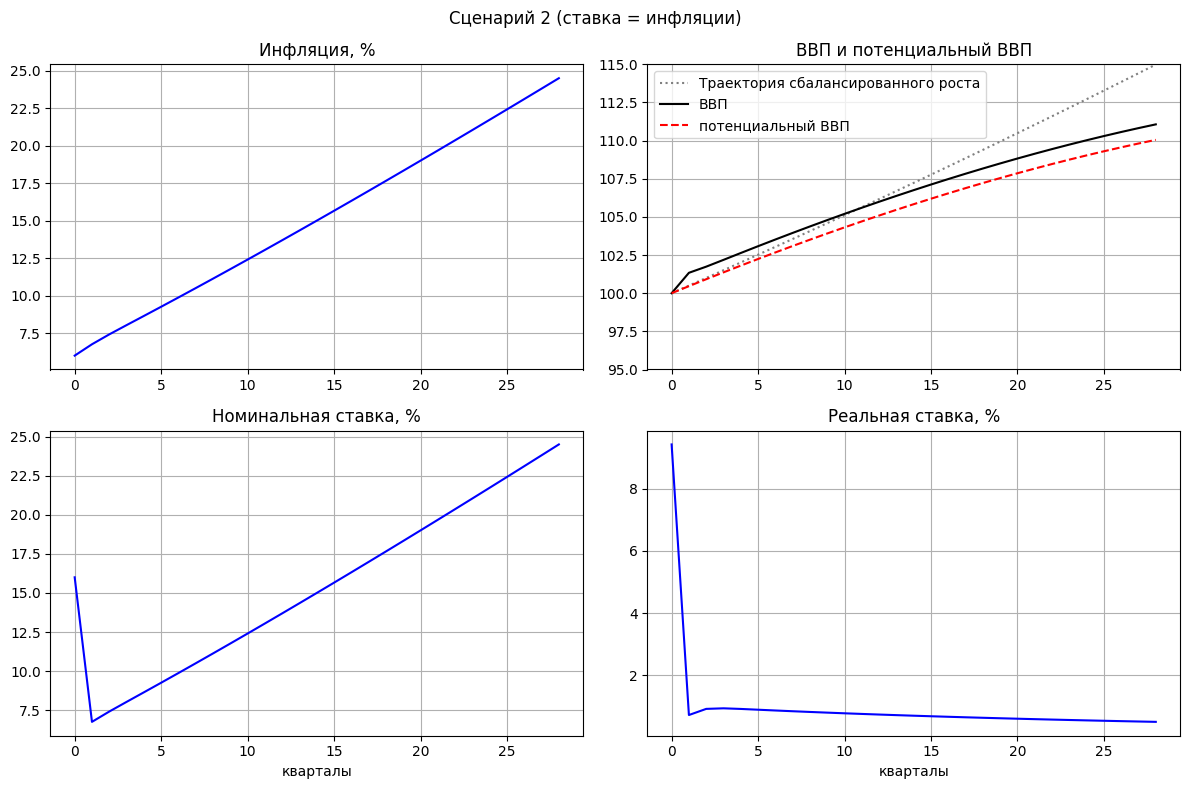

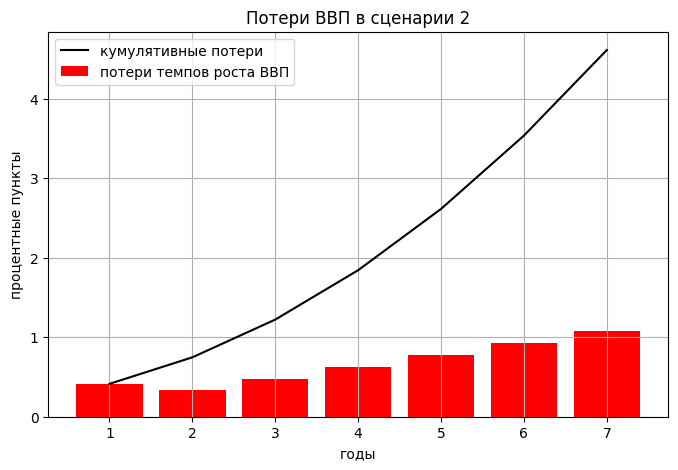

In [5]:
plot_main_indicators(scen2, 'Сценарий 2 (ставка = инфляции)')
plot_losses(scen2, 'Потери ВВП в сценарии 2')

##### График 3. Основные индикаторы — сценарий 3

Сценарий 3: один год ошибочной политики, затем переход на правило Тейлора. Видно, как корректировка меняет траектории.

*Соотвествует графикам на стр. 16 в записке цб рф*

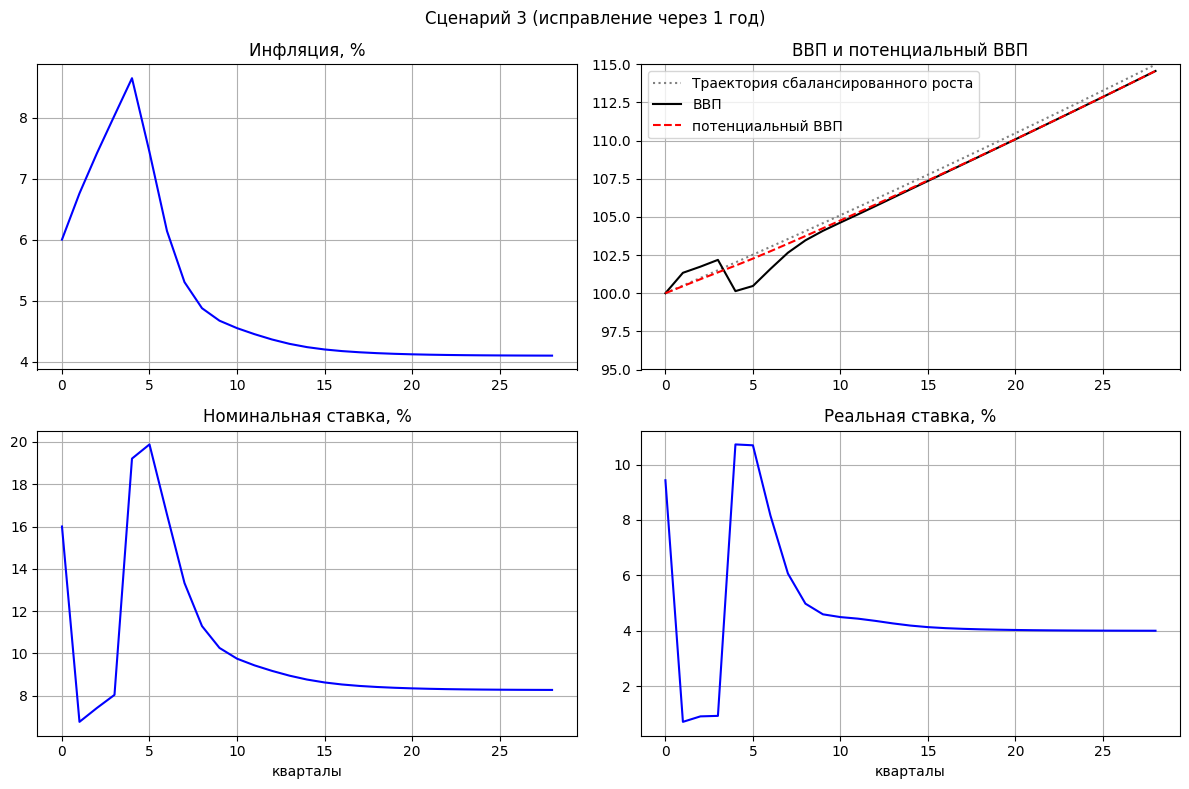

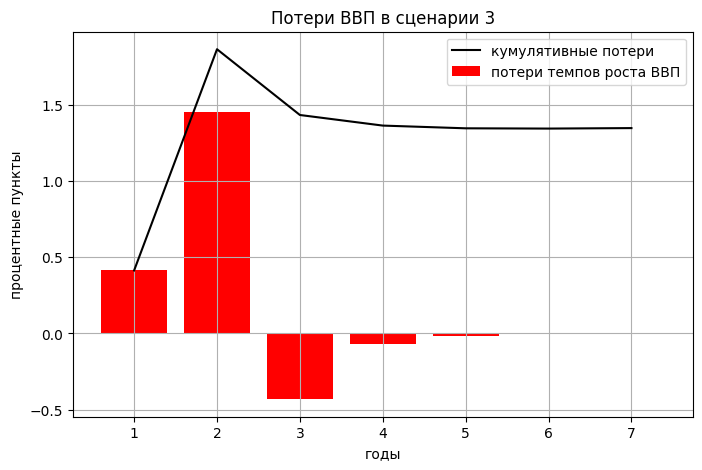

In [6]:
plot_main_indicators(scen3, 'Сценарий 3 (исправление через 1 год)')
plot_losses(scen3, 'Потери ВВП в сценарии 3')

##### График 4. Основные индикаторы — сценарий 4

Сценарий 4: более долгий период ошибочной политики (3 года), поэтому отклонения от устойчивой траектории обычно сильнее.

*Соотвествует графикам на стр. 17 в записке цб рф*

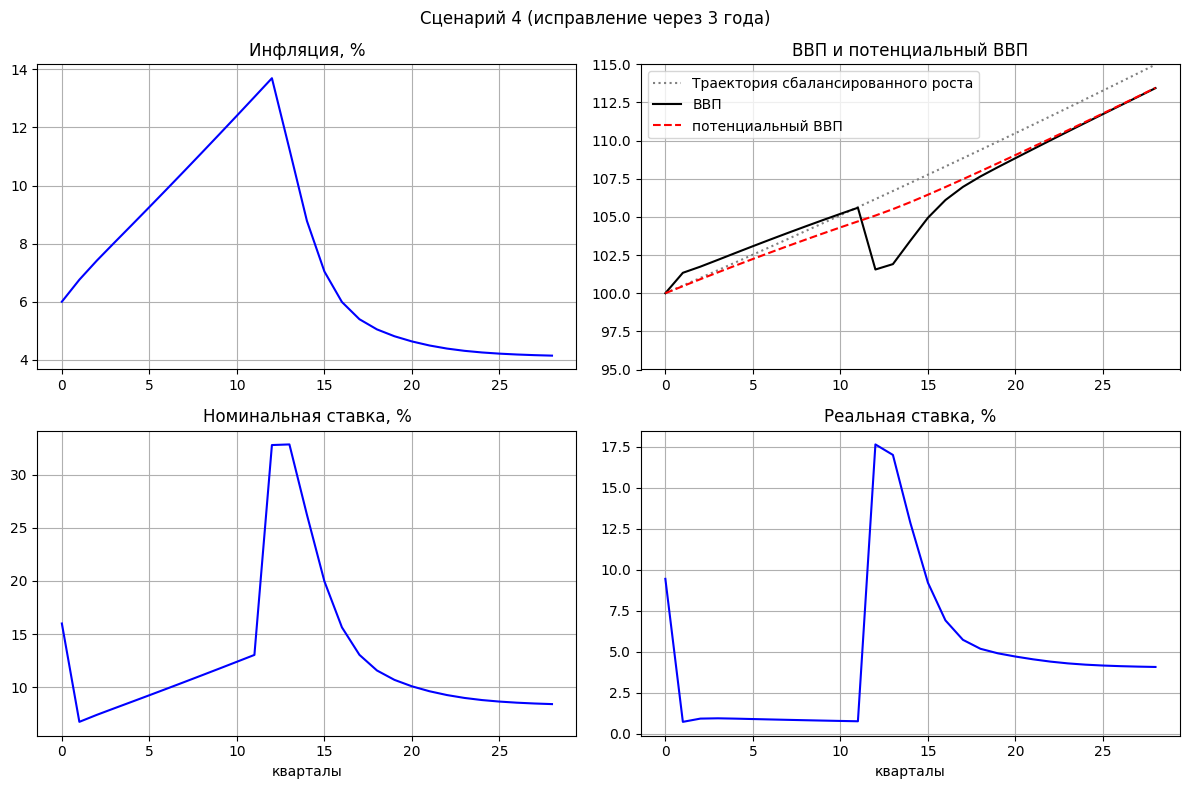

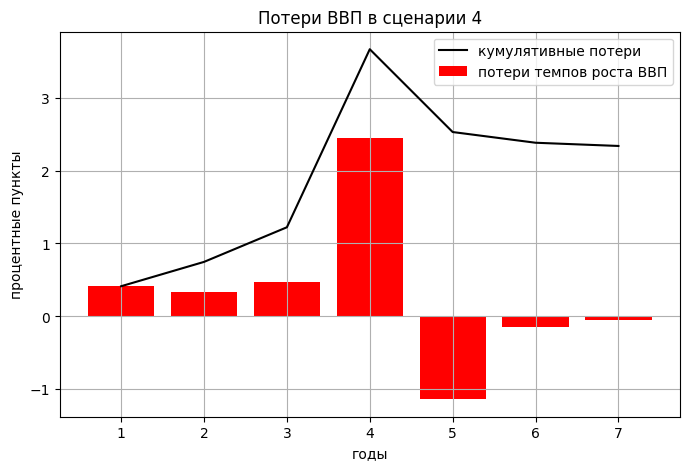

In [7]:
plot_main_indicators(scen4, 'Сценарий 4 (исправление через 3 года)')
plot_losses(scen4, 'Потери ВВП в сценарии 4')

#### Графики потерь ВВП

##### График 5. Потери ВВП — сценарий 1

Столбцы показывают годовые потери темпа роста ВВП, линия — накопленные потери.

*Соотвествует графику на стр. 12 в записке цб рф*

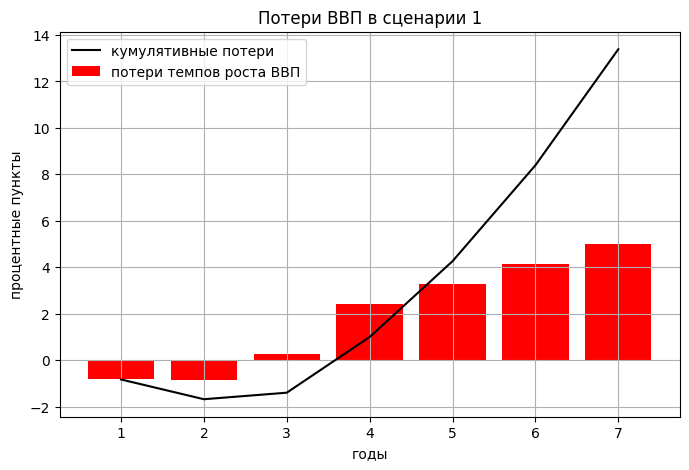

In [8]:
plot_losses(scen1, 'Потери ВВП в сценарии 1')

##### График 6. Потери ВВП — сценарий 2

Сравните форму столбцов и наклон кумулятивной линии со сценарием 1.

*Соотвествует графику на стр. 13 в записке цб рф*

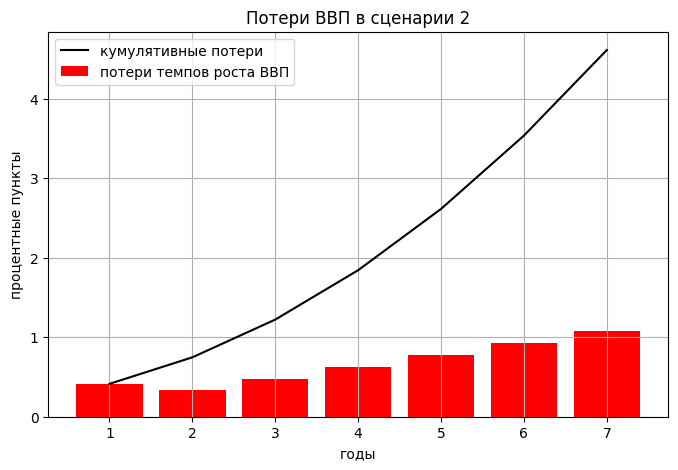

In [9]:
plot_losses(scen2, 'Потери ВВП в сценарии 2')

##### График 7. Потери ВВП — сценарий 3

После перехода к правилу Тейлора темп накопления потерь обычно меняется.

*Соотвествует графику на стр. 16 в записке цб рф*

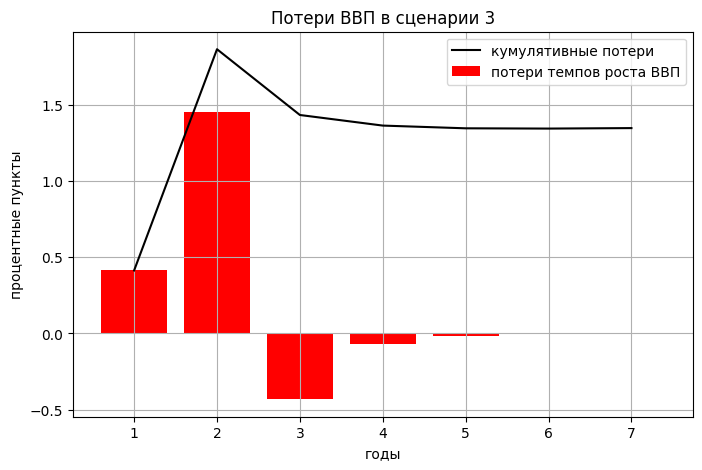

In [10]:
plot_losses(scen3, 'Потери ВВП в сценарии 3')

##### График 8. Потери ВВП — сценарий 4

Более длинная фаза ошибки политики отражается в более тяжёлой динамике потерь.

*Соотвествует графику на стр. 17 в записке цб рф*

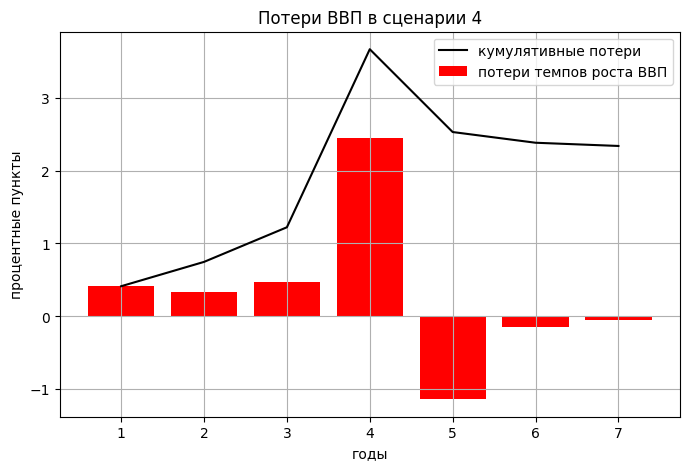

In [11]:
plot_losses(scen4, 'Потери ВВП в сценарии 4')

##### График 9. Сравнение кумулятивных потерь (рис. 10)

Этот график удобно использовать для итогового сравнения «цены» каждого сценария на одном поле.

*Соотвествует графику на стр. 18 в записке цб рф*

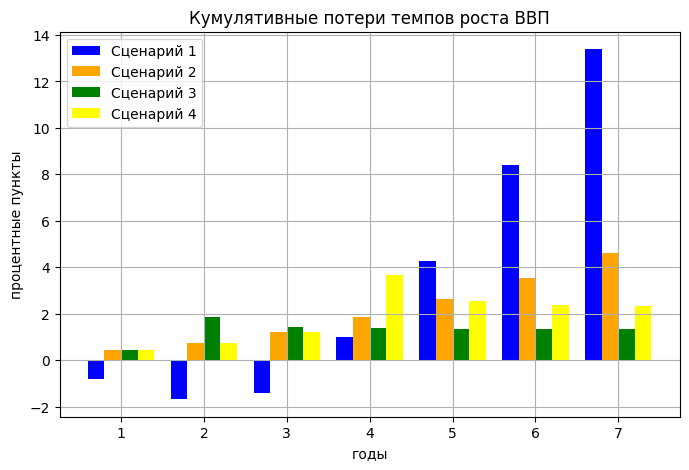

In [12]:
plot_cumulative_losses_comparison_4_results(scen1, scen2, scen3, scen4)

#### Графики сравнению ключевой ставки

##### Сравнение ключевой ставки в сценариях 3 и 4 (рис. 11)

*Соотвествует графику на стр. 18 в записке цб рф*

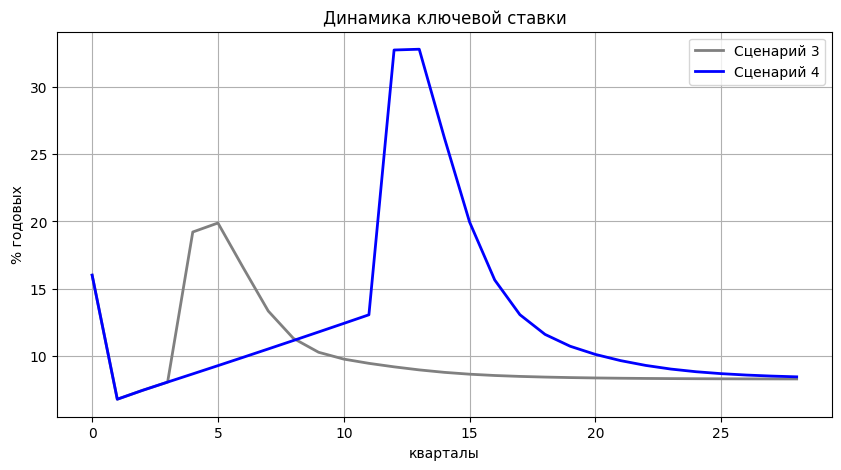

In [13]:
plot_key_rate_comparison(scen3, scen4)

##### Сравнение ключевой ставки по всем сценариям

*Этого графика нет в записке цб рф*

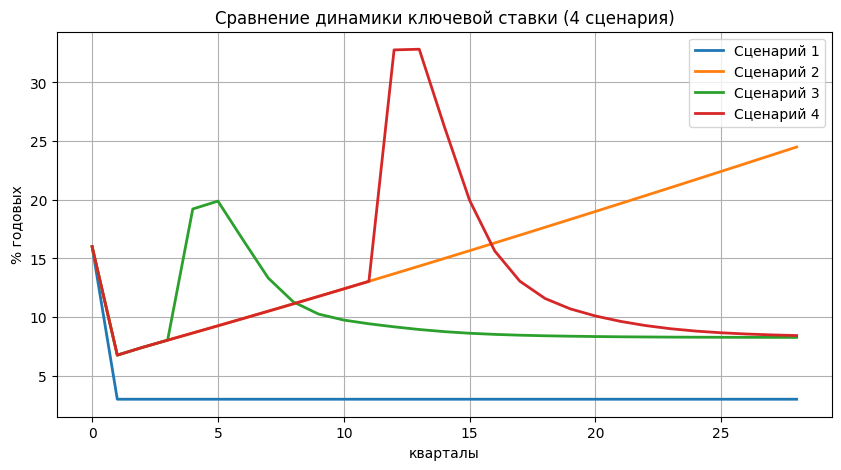

In [14]:
plot_key_rate_comparison_4_results(scen1, scen2, scen3, scen4)